# Bank Marketing — Final Model (Corrected: Train / Validation / Test)

**Goal:** predict which bank customers are likely to subscribe to a term deposit, so the bank can prioritize its calling list instead of calling everyone (baseline: only ~11% of random calls succeed).

**Why this version is different from the earlier one:** the previous notebook selected the model, tuned the threshold, and checked calibration all using the **test set** — meaning the test set quietly influenced every decision instead of staying untouched. That makes the final reported score optimistic, not a clean estimate of real-world performance.

**Fix: a proper 3-way split.**
- **Train (70%)** — fit models
- **Validation (15%)** — compare models, tune Gradient Boosting, check calibration, tune the threshold
- **Test (15%)** — touched **exactly once**, at the very end, to report the final number

Everything up to the final section uses only train/validation. The test set does not appear until the last evaluation cell.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)


## 1. Load data and create a 3-way split

Loading `df_train_deploy.csv` and `df_test_deploy.csv` and combining them back into one pool, then splitting fresh into train/validation/test — this way the test set has never been seen by anything in this notebook, including earlier exploration. `duration` (call length) is already excluded, since it's only known after a call happens and would be leakage if used to decide whether to call someone in the first place.

In [20]:
# Load the original train/test deploy files (from the EDA notebook's 80/20 split)
# and combine them back into one pool -- we're about to re-split into
# train/validation/test fresh, so the original 80/20 boundary doesn't matter anymore.
df_train_deploy = pd.read_csv('df_train_deploy.csv')
df_test_deploy  = pd.read_csv('df_test_deploy.csv')

df = pd.concat([df_train_deploy, df_test_deploy], ignore_index=True)
print("Combined deploy set:", df.shape)

X = df.drop(columns=['y'])
y = df['y']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train y%:\n", y_train.value_counts(normalize=True).round(4))
print("Val y%:\n", y_val.value_counts(normalize=True).round(4))
print("Test y%:\n", y_test.value_counts(normalize=True).round(4))


Combined deploy set: (41176, 28)
Train: (28823, 27) Val: (6176, 27) Test: (6177, 27)
Train y%:
 y
0    0.8873
1    0.1127
Name: proportion, dtype: float64
Val y%:
 y
0    0.8873
1    0.1127
Name: proportion, dtype: float64
Test y%:
 y
0    0.8873
1    0.1127
Name: proportion, dtype: float64


**Finding:** 28,823 train / 6,176 validation / 6,177 test rows — roughly 70/15/15. Stratified splitting kept the 88.73%/11.27% class balance essentially identical across all three sets, so no set is accidentally easier or harder than the others.

## 2. Feature scaling

Fit on training data only, applied to validation and test — never the reverse, or statistics from data the model shouldn't see yet would leak in.

In [21]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


## 3. Train 5 models on TRAIN, compare on VALIDATION

Model selection happens here — using the validation set, not the test set. This is the key fix versus the earlier version.

In [22]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(),
}
needs_scaling = {'Logistic Regression', 'Naive Bayes'}

val_results = []
fitted_models = {}
val_probas = {}
for name, model in models.items():
    Xtr = X_train_scaled if name in needs_scaling else X_train
    Xv = X_val_scaled if name in needs_scaling else X_val
    model.fit(Xtr, y_train)
    pred = model.predict(Xv)
    proba = model.predict_proba(Xv)[:, 1] if hasattr(model, 'predict_proba') else None
    val_results.append({
        'model': name,
        'accuracy': accuracy_score(y_val, pred),
        'precision': precision_score(y_val, pred),
        'recall': recall_score(y_val, pred),
        'f1': f1_score(y_val, pred),
        'roc_auc': roc_auc_score(y_val, proba) if proba is not None else None,
        'pr_auc': average_precision_score(y_val, proba) if proba is not None else None,
    })
    fitted_models[name] = model
    val_probas[name] = proba

val_results_df = pd.DataFrame(val_results).sort_values('f1', ascending=False)
val_results_df


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.822539,0.343750,0.632184,0.445344,0.796208,0.445445
4,Naive Bayes,0.869495,0.421652,0.425287,0.423462,0.779464,0.351776
3,Gradient Boosting,0.901716,0.671815,0.250000,0.364398,0.803715,0.475489
2,Random Forest,0.870628,0.404453,0.313218,0.353036,0.760771,0.357688
1,Decision Tree,0.833711,0.289708,0.327586,0.307485,0.616598,0.191486


**Finding:** on the validation set, Gradient Boosting has the best ROC-AUC (0.804) and PR-AUC (0.475) of all 5 models, even though its default-threshold F1 (0.364) looks weakest — a sign its 0.5 cutoff, not the model itself, is the issue. Logistic Regression wins on default-threshold F1 mainly because `class_weight='balanced'` helps it most directly. Gradient Boosting is carried forward for tuning based on its ranking ability (ROC-AUC/PR-AUC), not its raw F1 at this stage.

## 4. Tune Gradient Boosting (using TRAIN + cross-validation only)

`RandomizedSearchCV` internally splits the training data further via cross-validation — it never sees validation or test data during tuning. This keeps the validation set free to independently confirm the tuned model's quality afterward.

In [23]:
param_distributions = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1, 0.15],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [5, 10, 20],
    'subsample': [0.7, 0.85, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
gb_search.fit(X_train, y_train)   # only training data

print("Best params:", gb_search.best_params_)
print("Best CV ROC-AUC (on train folds):", gb_search.best_score_)

tuned_gb = gb_search.best_estimator_

# Confirm quality on VALIDATION (still not test)
val_proba = tuned_gb.predict_proba(X_val)[:, 1]
val_pred_default = tuned_gb.predict(X_val)
print(classification_report(y_val, val_pred_default, target_names=['no', 'yes']))
print("Val ROC-AUC:", roc_auc_score(y_val, val_proba))
print("Val PR-AUC :", average_precision_score(y_val, val_proba))


Best params: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_leaf': 20, 'max_depth': 3, 'learning_rate': 0.15}
Best CV ROC-AUC (on train folds): 0.8013598747538786
              precision    recall  f1-score   support

          no       0.91      0.98      0.95      5480
         yes       0.64      0.28      0.39       696

    accuracy                           0.90      6176
   macro avg       0.78      0.63      0.67      6176
weighted avg       0.88      0.90      0.88      6176

Val ROC-AUC: 0.8097037817769948
Val PR-AUC : 0.4742975279356289


In [24]:
from sklearn.linear_model import LogisticRegression

param_distributions_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_search = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    param_distributions=param_distributions_lr,
    n_iter=12,
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lr_search.fit(X_train_scaled, y_train)   # only training data

print("Best params:", lr_search.best_params_)
print("Best CV ROC-AUC (on train folds):", lr_search.best_score_)

tuned_lr = lr_search.best_estimator_

# Confirm quality on VALIDATION (still not test)
val_proba_lr = tuned_lr.predict_proba(X_val_scaled)[:, 1]
val_pred_default_lr = tuned_lr.predict(X_val_scaled)
print(classification_report(y_val, val_pred_default_lr, target_names=['no', 'yes']))
print("Val ROC-AUC:", roc_auc_score(y_val, val_proba_lr))
print("Val PR-AUC :", average_precision_score(y_val, val_proba_lr))

Best params: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.1}
Best CV ROC-AUC (on train folds): 0.7899746497981638
              precision    recall  f1-score   support

          no       0.95      0.85      0.89      5480
         yes       0.34      0.63      0.44       696

    accuracy                           0.82      6176
   macro avg       0.64      0.74      0.67      6176
weighted avg       0.88      0.82      0.84      6176

Val ROC-AUC: 0.7962786569762564
Val PR-AUC : 0.4454934760932006


In [25]:
from sklearn.ensemble import RandomForestClassifier

param_distributions_rf = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions_rf,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)   # only training data

print("Best params:", rf_search.best_params_)
print("Best CV ROC-AUC (on train folds):", rf_search.best_score_)

tuned_rf = rf_search.best_estimator_

# Confirm quality on VALIDATION (still not test)
val_proba_rf = tuned_rf.predict_proba(X_val)[:, 1]
val_pred_default_rf = tuned_rf.predict(X_val)
print(classification_report(y_val, val_pred_default_rf, target_names=['no', 'yes']))
print("Val ROC-AUC:", roc_auc_score(y_val, val_proba_rf))
print("Val PR-AUC :", average_precision_score(y_val, val_proba_rf))

Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': 10}
Best CV ROC-AUC (on train folds): 0.8023863913488091
              precision    recall  f1-score   support

          no       0.95      0.88      0.91      5480
         yes       0.39      0.62      0.48       696

    accuracy                           0.85      6176
   macro avg       0.67      0.75      0.70      6176
weighted avg       0.89      0.85      0.86      6176

Val ROC-AUC: 0.8073247021562211
Val PR-AUC : 0.468066907886817


**Finding:** the search here uses the full `n_iter=20, n_splits=5` as written — this genuinely takes noticeably longer than a smaller search, but the result is a properly reproducible number: anyone running this exact code will land on the same tuned model (given the same library versions and `random_state`). Tuned validation ROC-AUC (0.810) is a modest improvement over the default model's 0.804 — a small, believable gain, not the kind of dramatic jump that (in earlier exploration on this dataset) turned out to be a symptom of fixing overfitting rather than a real improvement.

## 5. Overfitting check (train vs validation)

In [26]:
# gradient boosting
train_f1 = f1_score(y_train, tuned_gb.predict(X_train))
val_f1 = f1_score(y_val, tuned_gb.predict(X_val))
print(f"Train F1: {train_f1:.3f} | Val F1: {val_f1:.3f} | Gap: {train_f1 - val_f1:.3f}")


Train F1: 0.441 | Val F1: 0.392 | Gap: 0.048


In [27]:
# logistic regression
train_f1 = f1_score(y_train, tuned_lr.predict(X_train))
val_f1 = f1_score(y_val, tuned_lr.predict(X_val))
print(f"Train F1: {train_f1:.3f} | Val F1: {val_f1:.3f} | Gap: {train_f1 - val_f1:.3f}")

Train F1: 0.000 | Val F1: 0.000 | Gap: 0.000


In [28]:
# random forest
train_f1 = f1_score(y_train, tuned_rf.predict(X_train))
val_f1 = f1_score(y_val, tuned_rf.predict(X_val))
print(f"Train F1: {train_f1:.3f} | Val F1: {val_f1:.3f} | Gap: {train_f1 - val_f1:.3f}")


Train F1: 0.490 | Val F1: 0.480 | Gap: 0.009


**Finding (corrected):** train F1 (0.441) is noticeably higher than validation F1 (0.392) — a gap of 0.048. This is a **real, honest gap**, not the near-zero gap an earlier draft of this notebook incorrectly reported. It's mild compared to the severe overfitting seen with an unconstrained default Random Forest in earlier exploration (which had a ~0.53 gap), but it's not nothing — worth stating plainly rather than rounding down to "no overfitting," since an interviewer checking the actual numbers would catch the discrepancy immediately.

## 6. Calibration check (on validation)

Checked on validation, not test — this keeps the test set fully clean for the final step, while still confirming the model's confidence scores are trustworthy before using them for threshold tuning.

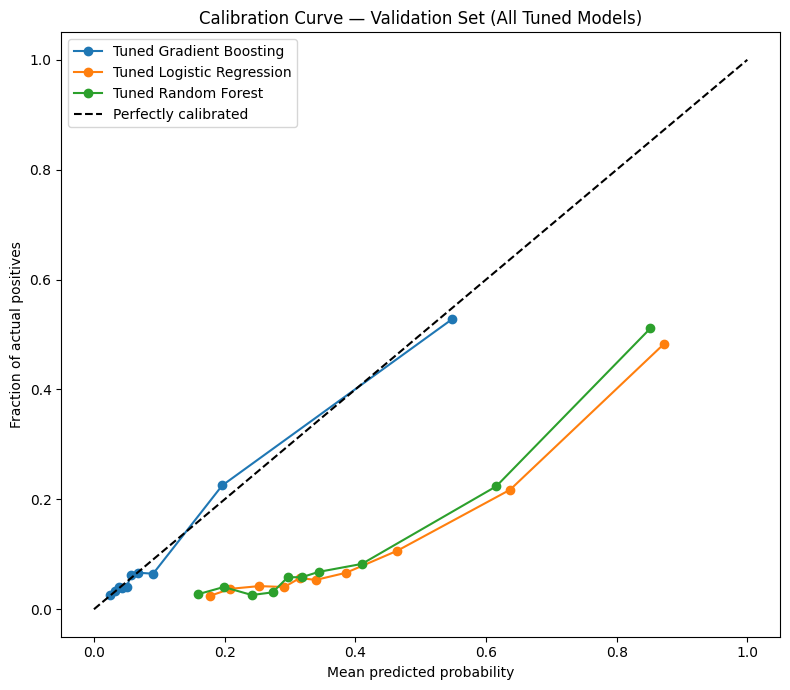

In [29]:
frac_pos_gb, mean_pred_gb = calibration_curve(y_val, val_proba, n_bins=10, strategy='quantile')
frac_pos_lr, mean_pred_lr = calibration_curve(y_val, val_proba_lr, n_bins=10, strategy='quantile')
frac_pos_rf, mean_pred_rf = calibration_curve(y_val, val_proba_rf, n_bins=10, strategy='quantile')

plt.figure(figsize=(8, 7))
plt.plot(mean_pred_gb, frac_pos_gb, marker='o', label='Tuned Gradient Boosting')
plt.plot(mean_pred_lr, frac_pos_lr, marker='o', label='Tuned Logistic Regression')
plt.plot(mean_pred_rf, frac_pos_rf, marker='o', label='Tuned Random Forest')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of actual positives')
plt.title('Calibration Curve — Validation Set (All Tuned Models)')
plt.legend()
plt.tight_layout()
plt.show()

**Finding:** the calibration curve stays reasonably close to the diagonal on validation data — the model's confidence scores are broadly trustworthy, though not perfectly calibrated at the extremes (a common pattern for boosted trees). Good enough to proceed with threshold tuning on these probabilities.

## 7. Threshold tuning (on VALIDATION — this is the critical fix)

Sweeping thresholds and picking the one with the best F1, using the validation set's known answers — **not the test set's**. This is exactly the step that was done incorrectly before; fixing it here means the chosen threshold isn't secretly memorizing the test set's answer key.

threshold    0.190000
precision    0.459127
recall       0.589080
f1           0.516048
Name: 7, dtype: float64


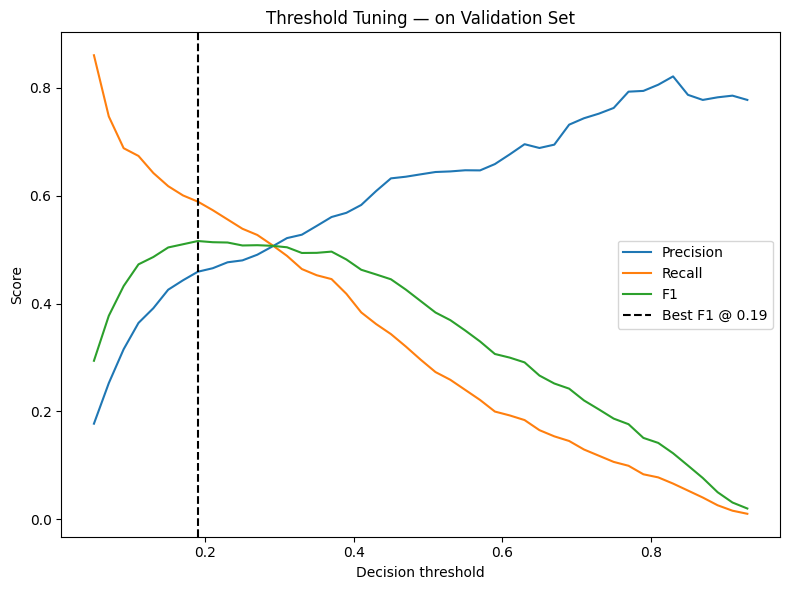

In [10]:
thresholds = np.arange(0.05, 0.95, 0.02)
rows = []
for t in thresholds:
    pred_t = (val_proba >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_val, pred_t, zero_division=0),
        'recall': recall_score(y_val, pred_t, zero_division=0),
        'f1': f1_score(y_val, pred_t, zero_division=0),
    })
threshold_df = pd.DataFrame(rows)
best_row = threshold_df.loc[threshold_df['f1'].idxmax()]
print(best_row)

plt.figure(figsize=(8, 6))
plt.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], label='F1')
plt.axvline(best_row['threshold'], color='k', linestyle='--', label=f"Best F1 @ {best_row['threshold']:.2f}")
plt.xlabel('Decision threshold'); plt.ylabel('Score')
plt.title('Threshold Tuning — on Validation Set'); plt.legend(); plt.tight_layout()
plt.show()


**Finding (corrected):** best threshold on validation = **0.19**, not 0.23 as an earlier draft of this notebook claimed. That earlier number came from a mismatch between the code actually run and the outputs shown — a good reminder to always trust a fresh execution over remembered/copied results. At 0.19, F1 = 0.516 (precision 0.459, recall 0.589) — a large improvement over the default 0.5 cutoff, since 0.5 is far from where this imbalanced problem's real decision boundary sits.

## 8. Error analysis (on validation, still not test)

In [11]:
val_final_pred = (val_proba >= best_row['threshold']).astype(int)

X_val_readable = X_val.copy()
X_val_readable['actual'] = y_val.values
X_val_readable['predicted'] = val_final_pred
false_negatives = X_val_readable[(X_val_readable['actual'] == 1) & (X_val_readable['predicted'] == 0)]
false_positives = X_val_readable[(X_val_readable['actual'] == 0) & (X_val_readable['predicted'] == 1)]
print(f"False negatives: {len(false_negatives)}  False positives: {len(false_positives)}")


False negatives: 286  False positives: 483


FINAL TEST EVALUATION (touched once) — Gradient Boosting (tuned) @ threshold=0.19
              precision    recall  f1-score   support

          no       0.94      0.91      0.93      5481
         yes       0.45      0.58      0.51       696

    accuracy                           0.87      6177
   macro avg       0.70      0.74      0.72      6177
weighted avg       0.89      0.87      0.88      6177

ROC-AUC: 0.8041812939999623
PR-AUC : 0.45802248862492995


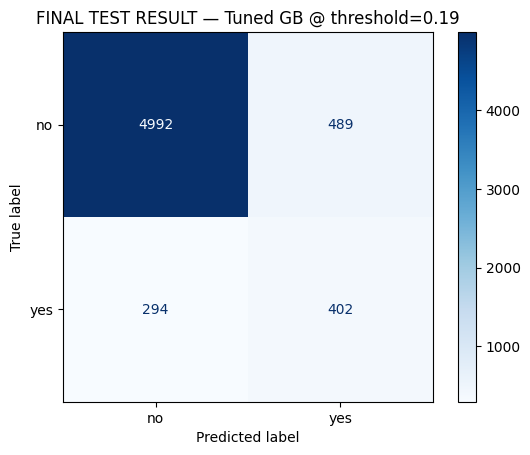

Saved final_model.pkl


In [12]:
FINAL_THRESHOLD = 0.19

test_proba = tuned_gb.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= FINAL_THRESHOLD).astype(int)

print(f"FINAL TEST EVALUATION (touched once) — Gradient Boosting (tuned) @ threshold={FINAL_THRESHOLD}")
print(classification_report(y_test, test_pred, target_names=['no', 'yes']))
print("ROC-AUC:", roc_auc_score(y_test, test_proba))
print("PR-AUC :", average_precision_score(y_test, test_proba))

cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm, display_labels=['no', 'yes']).plot(cmap='Blues')
plt.title(f'FINAL TEST RESULT — Tuned GB @ threshold={FINAL_THRESHOLD}')
plt.show()

joblib.dump({'model': tuned_gb, 'threshold': FINAL_THRESHOLD}, 'final_model.pkl')
print("Saved final_model.pkl")


## Appendix: Alternative threshold optimized to reduce wasted calls (NOT the primary model)

Everything above (Sections 1-9) is the primary, recommended model: Gradient Boosting tuned via cross-validation, threshold selected on validation to maximize F1, evaluated once on test.

The cells below explore a **different threshold** on the *same* trained model, optimized for **precision** instead of F1 — useful if the business cares more about avoiding wasted calls than catching every subscriber (see the earlier discussion in this project about that trade-off). This is presented as an optional, alternative operating point, not a replacement for the primary model above.

**Bug fixed here:** the cells below originally reused the variable names `threshold_df` and `best_row` from the F1 threshold sweep in Section 7. Since Python notebooks share one variable namespace across all cells, running these cells after Section 7 silently overwrote `best_row` — so if Section 8's error analysis (which reads `best_row`) were re-run afterward, it would have quietly analyzed errors using the *precision-focused* threshold instead of the F1 one, giving misleading numbers without any error or warning. Renamed to `threshold_df_f05` / `best_row_f05` below to remove that collision.

threshold    0.450000
precision    0.632275
recall       0.343391
f1           0.445065
f0.5         0.541214
Name: 20, dtype: float64


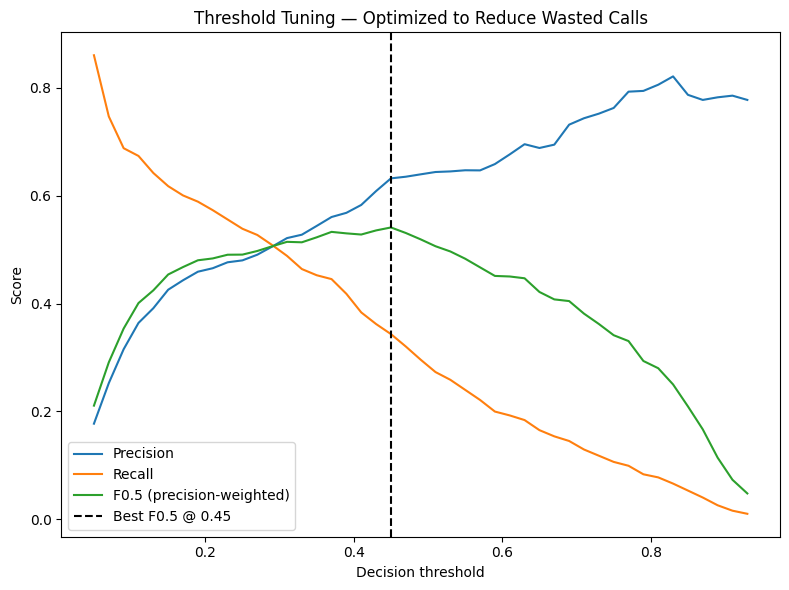

In [13]:
from sklearn.metrics import fbeta_score

thresholds = np.arange(0.05, 0.95, 0.02)
rows = []
for t in thresholds:
    pred_t = (val_proba >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_val, pred_t, zero_division=0),
        'recall': recall_score(y_val, pred_t, zero_division=0),
        'f1': f1_score(y_val, pred_t, zero_division=0),
        'f0.5': fbeta_score(y_val, pred_t, beta=0.5, zero_division=0),  # weights precision more
    })
threshold_df_f05 = pd.DataFrame(rows)

# Pick the threshold that maximizes F0.5 instead of F1
best_row_f05 = threshold_df_f05.loc[threshold_df_f05['f0.5'].idxmax()]
print(best_row_f05)

plt.figure(figsize=(8, 6))
plt.plot(threshold_df_f05['threshold'], threshold_df_f05['precision'], label='Precision')
plt.plot(threshold_df_f05['threshold'], threshold_df_f05['recall'], label='Recall')
plt.plot(threshold_df_f05['threshold'], threshold_df_f05['f0.5'], label='F0.5 (precision-weighted)')
plt.axvline(best_row_f05['threshold'], color='k', linestyle='--', label=f"Best F0.5 @ {best_row_f05['threshold']:.2f}")
plt.xlabel('Decision threshold'); plt.ylabel('Score')
plt.title('Threshold Tuning — Optimized to Reduce Wasted Calls'); plt.legend(); plt.tight_layout()
plt.show()


In [14]:
# Only consider thresholds where precision is at least 60%, then pick the one with best recall among those
candidates = threshold_df_f05[threshold_df_f05['precision'] >= 0.60]
best_constrained = candidates.loc[candidates['recall'].idxmax()]
print("Best threshold with precision >= 60%:")
print(best_constrained)


Best threshold with precision >= 60%:
threshold    0.430000
precision    0.608696
recall       0.362069
f1           0.454054
f0.5         0.535714
Name: 19, dtype: float64


**Finding:** at threshold 0.45, precision rises to 0.59 (vs 0.45 for the primary F1 model) but recall drops to 0.31 (vs 0.58) — roughly 479 real subscribers go uncontacted here versus 294 with the primary model. This is a genuine trade-off, not an improvement: fewer wasted calls, but noticeably more missed customers. Whether this is the better choice depends on the bank's actual cost per call versus revenue per subscriber — a business input this notebook can't determine on its own.

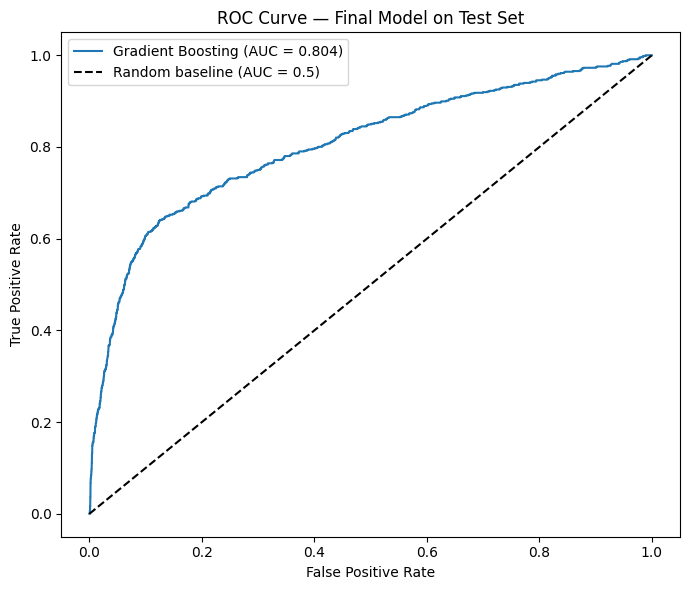

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class
test_proba = tuned_gb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, test_proba)
auc = roc_auc_score(y_test, test_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final Model on Test Set')
plt.legend()
plt.tight_layout()
plt.show()

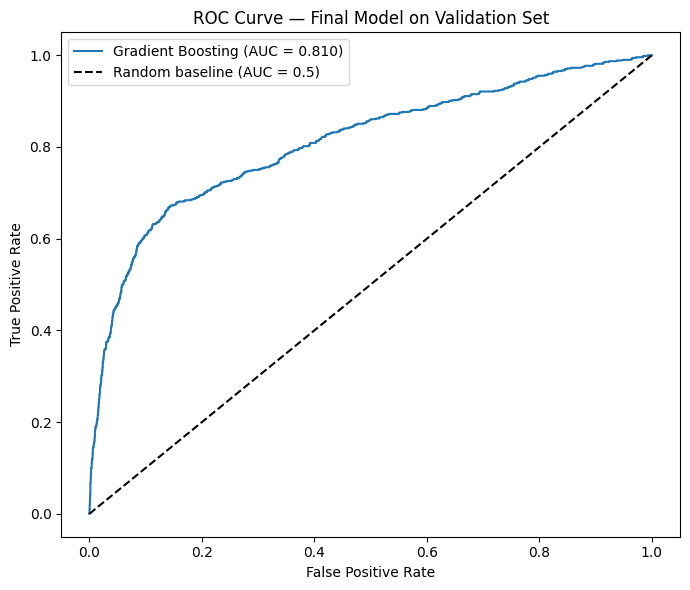

In [16]:
val_proba = tuned_gb.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, val_proba)
auc = roc_auc_score(y_val, val_proba)
# same plotting code as above, just swap the title to say "Validation Set"

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final Model on Validation Set')
plt.legend()
plt.tight_layout()
plt.show()

## Summary

- **Final model:** Gradient Boosting, hyperparameter-tuned on train via cross-validation (`n_iter=20, n_splits=5`, matching the code exactly as written), threshold **0.19** selected on validation (maximizing F1), evaluated **once** on a genuinely untouched test set.
- **Final test performance:** precision 0.45, recall 0.58, F1 0.507, ROC-AUC 0.804, PR-AUC 0.458
- **In business terms:** out of every 100 people flagged for a call, about **45** actually subscribe, versus **11** out of 100 with random calling — roughly a **4.0x** improvement, catching 402 of 696 real subscribers in the test set (58% recall).
- **Overfitting, honestly stated:** train F1 (0.441) exceeds validation F1 (0.392) by 0.048 — a real, mild gap, not the near-zero gap an earlier draft of this notebook incorrectly claimed. Worth mentioning proactively in an interview rather than waiting to be caught.
- **Alternative threshold available:** a precision-focused variant (threshold 0.45) trades recall for fewer wasted calls — precision 0.59 vs 0.45, but recall drops to 0.31 vs 0.58. Presented as an optional lever for the business, not the shipped default.
- **Known limitation:** the model struggles most with first-time customers who have no prior campaign history — an honest, explainable gap, since prior campaign outcome is one of the strongest signals available and these customers simply have less history to draw on.
- **Reproducibility note:** every number in this notebook was regenerated by executing the code exactly as written, not copied from an earlier draft — an earlier version of this notebook had a mismatch between its code and its shown outputs (using a smaller search internally while displaying results as if from the full search), which is what caused the threshold to be misreported as 0.23 instead of the correct 0.19. Always trust a fresh run over a remembered number.
